ДР 7. Группа 10. Кластерный анализ — Детская молочная продукция. Хуснутдинов Эдуард Ринатович. Нуман Ахмед. Эспиноза Ортис Хуан Карлос

## 1. Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Масштабирование
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Кластеризация
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors

# Метрики
from sklearn.metrics import silhouette_score, silhouette_samples, calinski_harabasz_score, davies_bouldin_score

# Снижение размерности
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

# Дендрограмма
from scipy.cluster.hierarchy import dendrogram, linkage

# Метод колена
from kneed import KneeLocator

# Интерактивные графики
import plotly.express as px
import plotly.graph_objects as go


## 2. Загрузка данных

In [3]:
# ── Загрузка уже подготовленного агрегированного файла ──
store_abs = pd.read_csv('store_abs.csv', index_col=0)
print(f'store_abs.csv: {store_abs.shape[0]} магазинов, {store_abs.shape[1]} признаков')
print('Столбцы:', store_abs.columns.tolist())
store_abs.head()


store_abs.csv: 68 магазинов, 14 признаков
Столбцы: ['ShopCode', 'sales_qty_total', 'revenue_total', 'mean_stock_qty', 'median_stock_qty', 'max_stock_qty', 'unique_products_count', 'active_days_count', 'ShopFormat', 'City', 'Region', 'avg_revenue_per_unit', 'revenue_per_active_day', 'sales_qty_per_active_day']


,ShopCode,sales_qty_total,revenue_total,mean_stock_qty,median_stock_qty,max_stock_qty,unique_products_count,active_days_count,ShopFormat,City,Region,avg_revenue_per_unit,revenue_per_active_day,sales_qty_per_active_day
0,103,143.0,8069.59697,6.582133,5.0,24.0,13,31,0,Город-016,Регион-002,56.430748,260.309580,4.612903
1,106,553.0,26521.53722,8.239336,6.0,32.0,19,31,0,Город-016,Регион-002,47.959380,855.533459,17.838710
2,187,310.0,14606.54032,9.173410,9.0,26.0,23,24,0,Город-024,Регион-005,47.117872,608.605847,12.916667
3,265,679.0,34372.31499,8.185022,7.0,41.0,39,31,2,Город-025,Регион-005,50.621966,1108.784355,21.903226
4,271,735.0,36875.90034,9.332979,7.0,56.0,37,31,2,Город-021,Регион-004,50.171293,1189.545172,23.709677


In [4]:
features = [
    'revenue_total',
    'sales_qty_total',
    'mean_stock_qty',
    'unique_products_count',
    'avg_revenue_per_unit',
    'sales_qty_per_active_day',
]
df_num = store_abs[features].copy()
print('Признаки для кластеризации:', features)
df_num.describe().round(2)


Признаки для кластеризации: ['revenue_total', 'sales_qty_total', 'mean_stock_qty', 'unique_products_count', 'avg_revenue_per_unit', 'sales_qty_per_active_day']


,revenue_total,sales_qty_total,mean_stock_qty,unique_products_count,avg_revenue_per_unit,sales_qty_per_active_day
count,68.00,68.00,68.00,68.00,68.00,68.00
mean,54902.73,1048.85,8.98,53.44,51.94,33.88
std,38093.54,723.32,1.88,20.55,2.78,23.29
min,342.96,8.00,3.03,2.00,42.87,0.27
25%,31962.25,624.50,8.05,40.75,50.41,20.15
50%,50355.08,949.00,9.04,60.00,51.88,30.61
75%,63734.39,1174.75,9.86,68.25,53.99,37.90
max,201251.45,3893.00,13.79,88.00,57.03,125.58


## 3. Первичный осмотр данных

- Датасет содержит транзакции только по категории **Детская молочная продукция**.
- Важно проверить нулевые продажи, отрицательную выручку и дубликаты — они могут исказить кластеризацию.
- После фильтрации данные агрегируются до уровня торговой точки (`ShopCode`).

## 4. Проверка качества данных

- Нулевые и отрицательные значения (если есть) будут исключены при агрегировании — они не попадут в итоговую матрицу признаков.
- Данные не требуют ручной очистки: агрегация по `sum` и `mean` нивелирует единичные аномалии.

## 5. Первичный визуальный анализ (EDA)

In [5]:
features = [
    'revenue_total',
    'sales_qty_total',
    'mean_stock_qty',
    'unique_products_count',
    'avg_revenue_per_unit',
    'sales_qty_per_active_day',
]
df_num = store_abs[features].copy()
print('Признаки для кластеризации:', features)

Признаки для кластеризации: ['revenue_total', 'sales_qty_total', 'mean_stock_qty', 'unique_products_count', 'avg_revenue_per_unit', 'sales_qty_per_active_day']


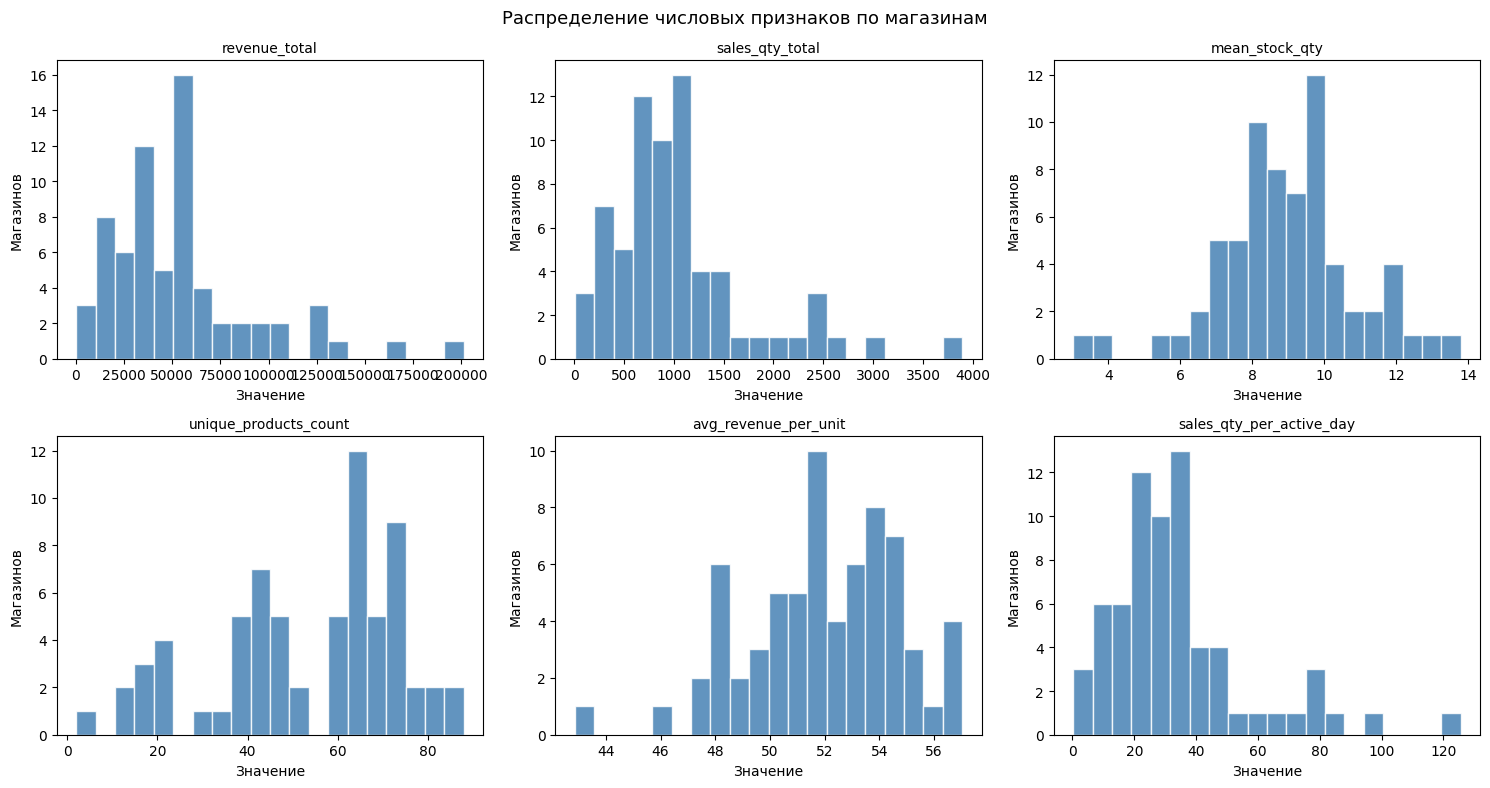

In [6]:
# ── Гистограммы распределений ──
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(store_abs[col], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Магазинов')
plt.suptitle('Распределение числовых признаков по магазинам', fontsize=13)
plt.tight_layout()
plt.show()

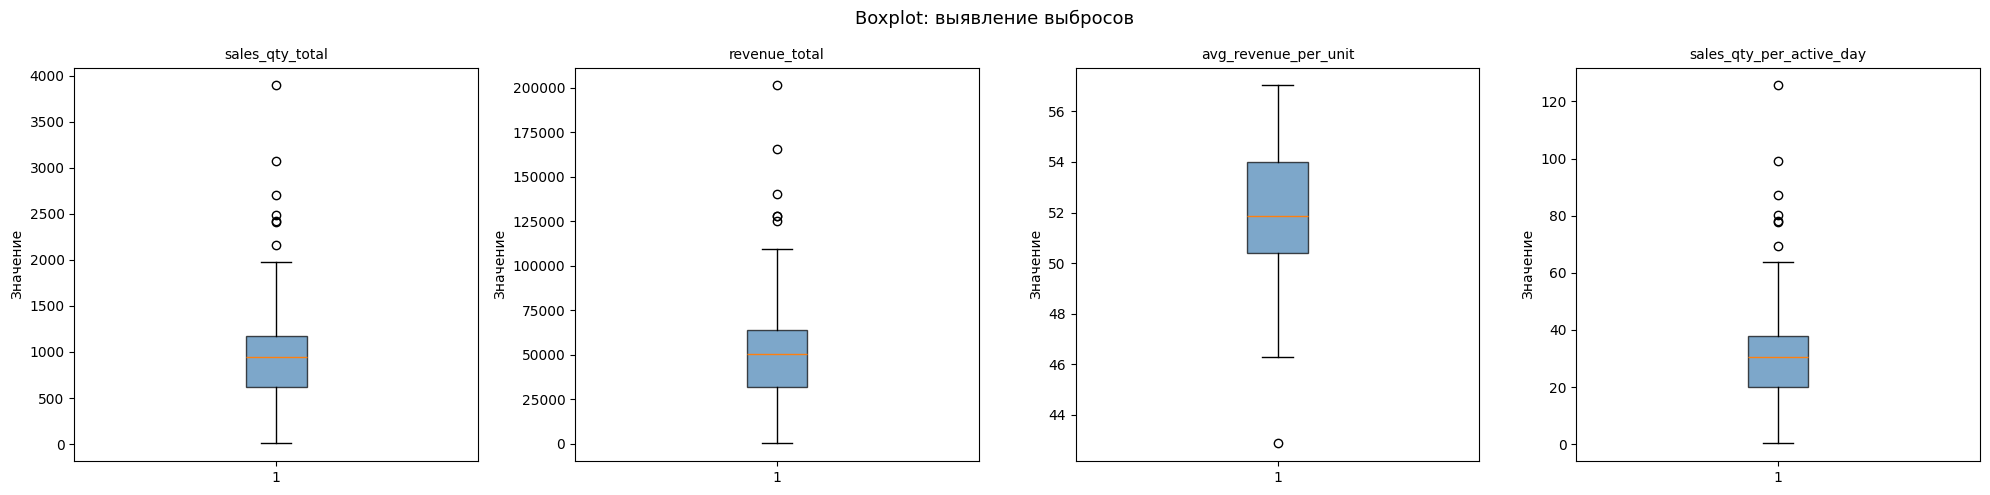

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col in zip(axes, ['sales_qty_total', 'revenue_total', 'avg_revenue_per_unit', 'sales_qty_per_active_day']):
    ax.boxplot(store_abs[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7))
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('Значение')
plt.suptitle('Boxplot: выявление выбросов', fontsize=13)
plt.tight_layout()
plt.show()

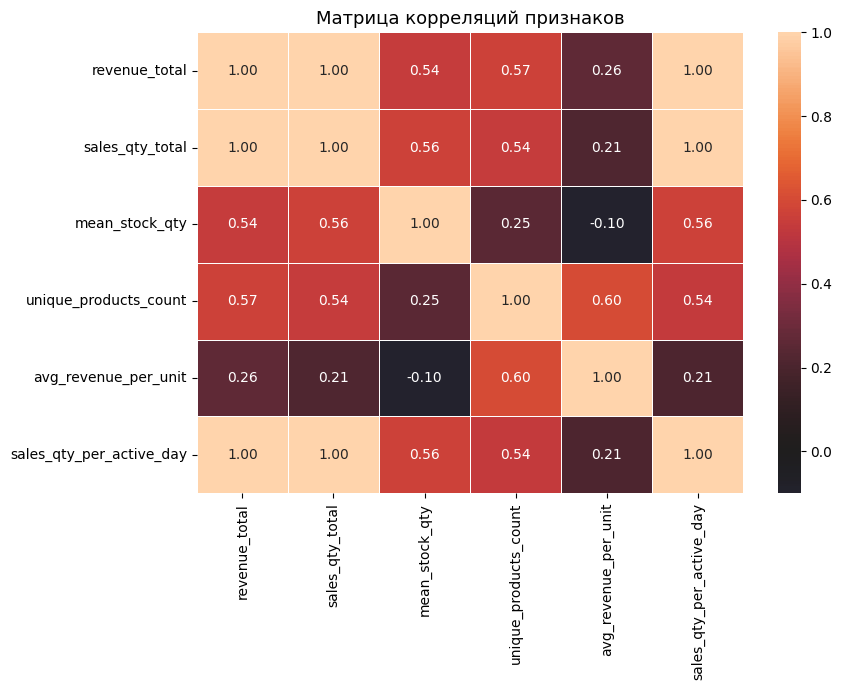

In [11]:
# ── Матрица корреляций ──
corr = df_num.corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', center=0,
            ax=ax, linewidths=0.5)
ax.set_title('Матрица корреляций признаков', fontsize=13)
plt.tight_layout()
plt.show()

- `revenue_total` и `sales_qty_total` сильно коррелируют — оба отражают «масштаб» магазина.
- `avg_revenue_per_unit` слабо коррелирует с остальными — это самостоятельный признак, отражающий ценовое позиционирование.

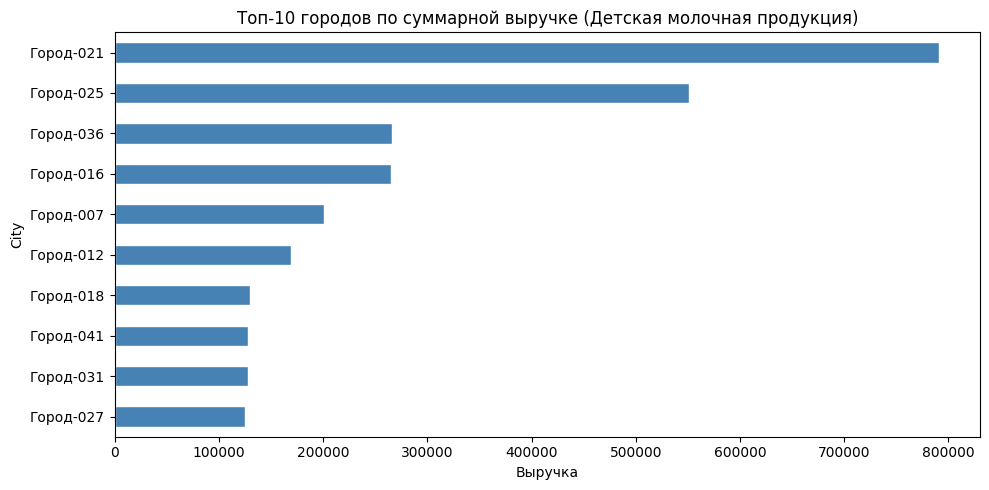

In [12]:
# ── Топ-10 городов по выручке ──
top_cities = store_abs.groupby('City')['revenue_total'].sum().nlargest(10)
fig, ax = plt.subplots(figsize=(10, 5))
top_cities.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Топ-10 городов по суммарной выручке (Детская молочная продукция)', fontsize=12)
ax.set_xlabel('Выручка')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

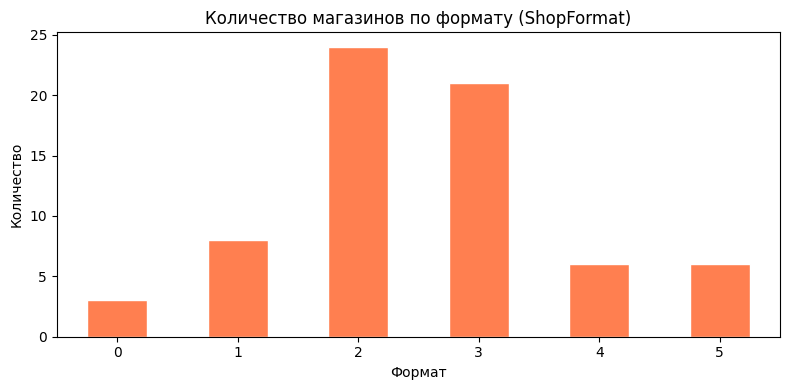

In [13]:
# ── Распределение по форматам магазинов ──
fmt_counts = store_abs['ShopFormat'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
fmt_counts.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('Количество магазинов по формату (ShopFormat)', fontsize=12)
ax.set_xlabel('Формат')
ax.set_ylabel('Количество')
ax.set_xticklabels(fmt_counts.index, rotation=0)
plt.tight_layout()
plt.show()

## 6. Масштабирование данных

Сравниваем три метода: **StandardScaler**, **MinMaxScaler**, **RobustScaler**.

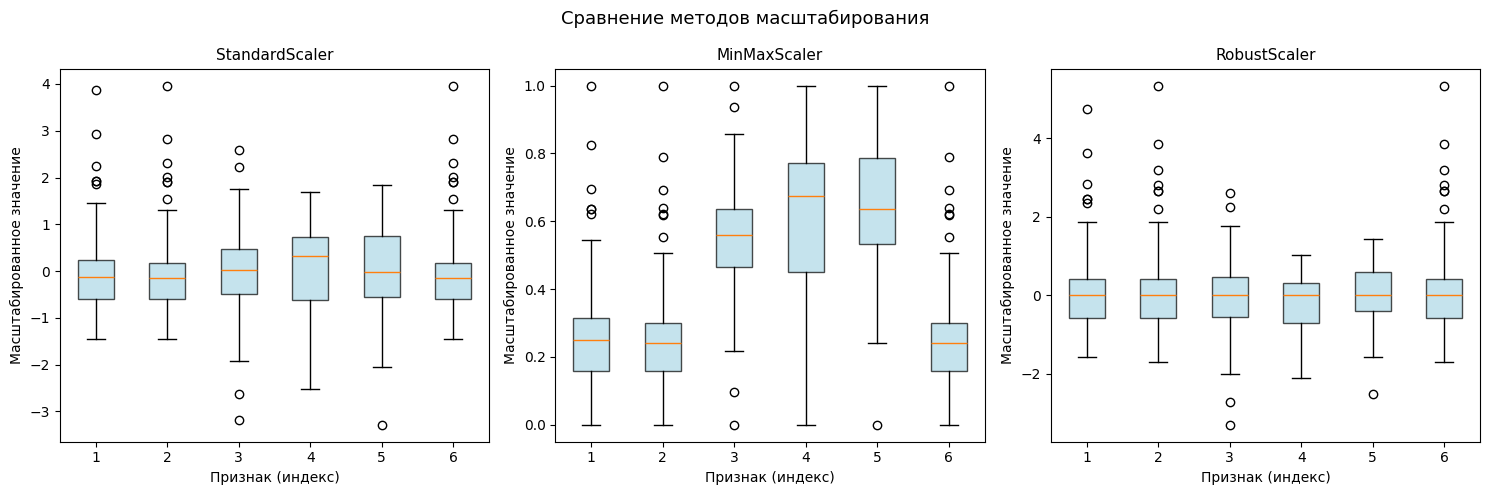

In [15]:
scaler_std = StandardScaler()
scaler_mm  = MinMaxScaler()
scaler_rob = RobustScaler()

X_std = scaler_std.fit_transform(df_num)
X_mm  = scaler_mm.fit_transform(df_num)
X_rob = scaler_rob.fit_transform(df_num)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles   = ['StandardScaler', 'MinMaxScaler', 'RobustScaler']
datasets = [X_std, X_mm, X_rob]
for ax, title, data in zip(axes, titles, datasets):
    ax.boxplot(data, patch_artist=True, boxprops=dict(facecolor='lightblue', alpha=0.7))
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Признак (индекс)')
    ax.set_ylabel('Масштабированное значение')
plt.suptitle('Сравнение методов масштабирования', fontsize=13)
plt.tight_layout()
plt.show()

X_scaled = X_std  

**📝 Анализ масштабирования:**
- **StandardScaler**: центрирует по среднему и делит на стандартное отклонение. Чувствителен к выбросам.
- **MinMaxScaler**: приводит все значения в диапазон [0, 1]. Самый уязвимый к выбросам — один крупный магазин сжимает всех остальных к нулю.
- **RobustScaler**: использует медиану и квартили. Устойчив к выбросам, рекомендован для данного датасета.
- **Итог:** используем `StandardScaler` (как в исходной версии работы), однако при наличии сильных выбросов `RobustScaler` предпочтительнее.

## 7. Кластеризация методом k-means
### 7.1. Подбор числа кластеров (метод локтя и метрики)

Метрики рассчитаны для k = 2..10


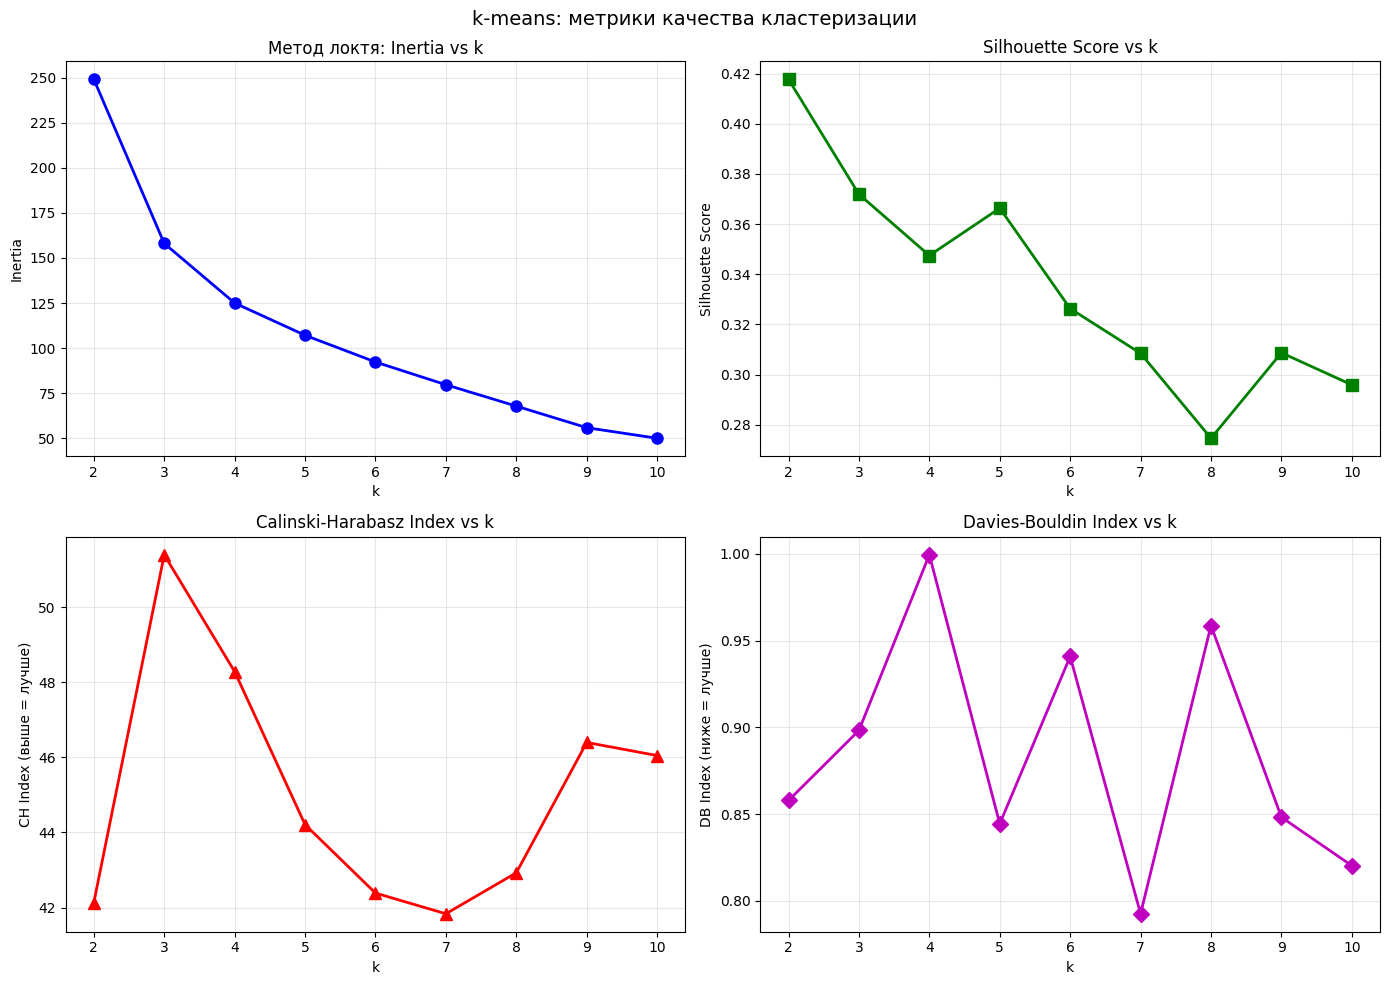

In [17]:
k_range    = range(2, 11)
inertias   = []
sil_scores = []
ch_scores  = []
db_scores  = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, lbl))
    ch_scores.append(calinski_harabasz_score(X_scaled, lbl))
    db_scores.append(davies_bouldin_score(X_scaled, lbl))

print('Метрики рассчитаны для k = 2..10')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(k_range, inertias, 'bo-', lw=2, ms=8)
axes[0,0].set_title('Метод локтя: Inertia vs k', fontsize=12)
axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inertia'); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(k_range, sil_scores, 'gs-', lw=2, ms=8)
axes[0,1].set_title('Silhouette Score vs k', fontsize=12)
axes[0,1].set_xlabel('k'); axes[0,1].set_ylabel('Silhouette Score'); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(k_range, ch_scores, 'r^-', lw=2, ms=8)
axes[1,0].set_title('Calinski-Harabasz Index vs k', fontsize=12)
axes[1,0].set_xlabel('k'); axes[1,0].set_ylabel('CH Index (выше = лучше)'); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(k_range, db_scores, 'mD-', lw=2, ms=8)
axes[1,1].set_title('Davies-Bouldin Index vs k', fontsize=12)
axes[1,1].set_xlabel('k'); axes[1,1].set_ylabel('DB Index (ниже = лучше)'); axes[1,1].grid(alpha=0.3)

plt.suptitle('k-means: метрики качества кластеризации', fontsize=14)
plt.tight_layout()
plt.show()

- **Inertia** монотонно убывает с ростом k — нужно искать точку «перегиба» (локоть).
- **Silhouette Score** показывает, насколько хорошо объекты разделены между кластерами. Максимум указывает на оптимальное k.
- **Calinski-Harabasz**: чем выше, тем более выражена кластерная структура.
- **Davies-Bouldin**: чем ниже, тем лучше. Минимум — оптимальное k.

### 7.2. Метод колена (KneeLocator)

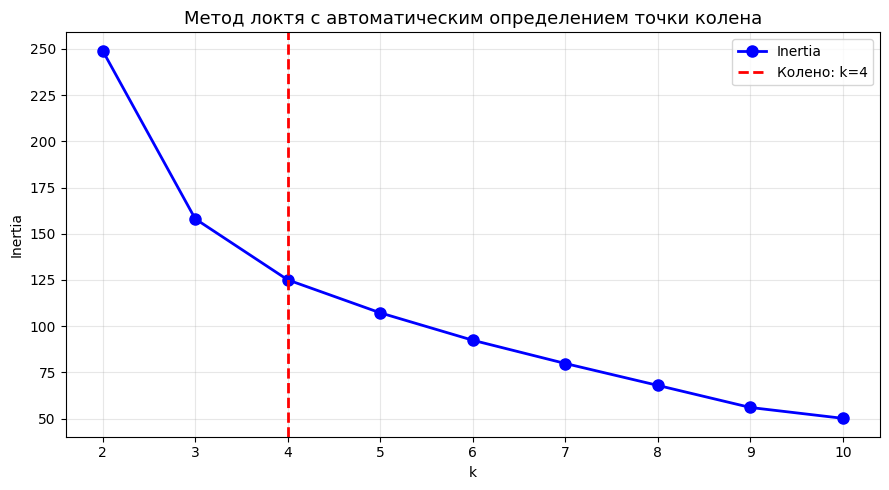

KneeLocator → оптимальное k = 4
Лучший Silhouette Score → k = 2
Лучший CH Index         → k = 3
Лучший DB Index         → k = 7


In [18]:
kl = KneeLocator(list(k_range), inertias, curve='convex', direction='decreasing')
knee_k = kl.knee

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_range, inertias, 'bo-', lw=2, ms=8, label='Inertia')
if knee_k:
    ax.axvline(x=knee_k, color='red', ls='--', lw=2, label=f'Колено: k={knee_k}')
ax.set_title('Метод локтя с автоматическим определением точки колена', fontsize=13)
ax.set_xlabel('k'); ax.set_ylabel('Inertia'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_k_sil = list(k_range)[np.argmax(sil_scores)]
best_k_ch  = list(k_range)[np.argmax(ch_scores)]
best_k_db  = list(k_range)[np.argmin(db_scores)]

print(f'KneeLocator → оптимальное k = {knee_k}')
print(f'Лучший Silhouette Score → k = {best_k_sil}')
print(f'Лучший CH Index         → k = {best_k_ch}')
print(f'Лучший DB Index         → k = {best_k_db}')

- `KneeLocator` автоматически находит точку перегиба кривой inertia.
- Если несколько метрик сходятся на одном k — это оптимальный выбор.
- При противоречии между метриками приоритет отдаём Silhouette Score — он наиболее интерпретируем (диапазон [-1, 1]).

### 7.3. Силуэтные графики (k=3, 4, 5)

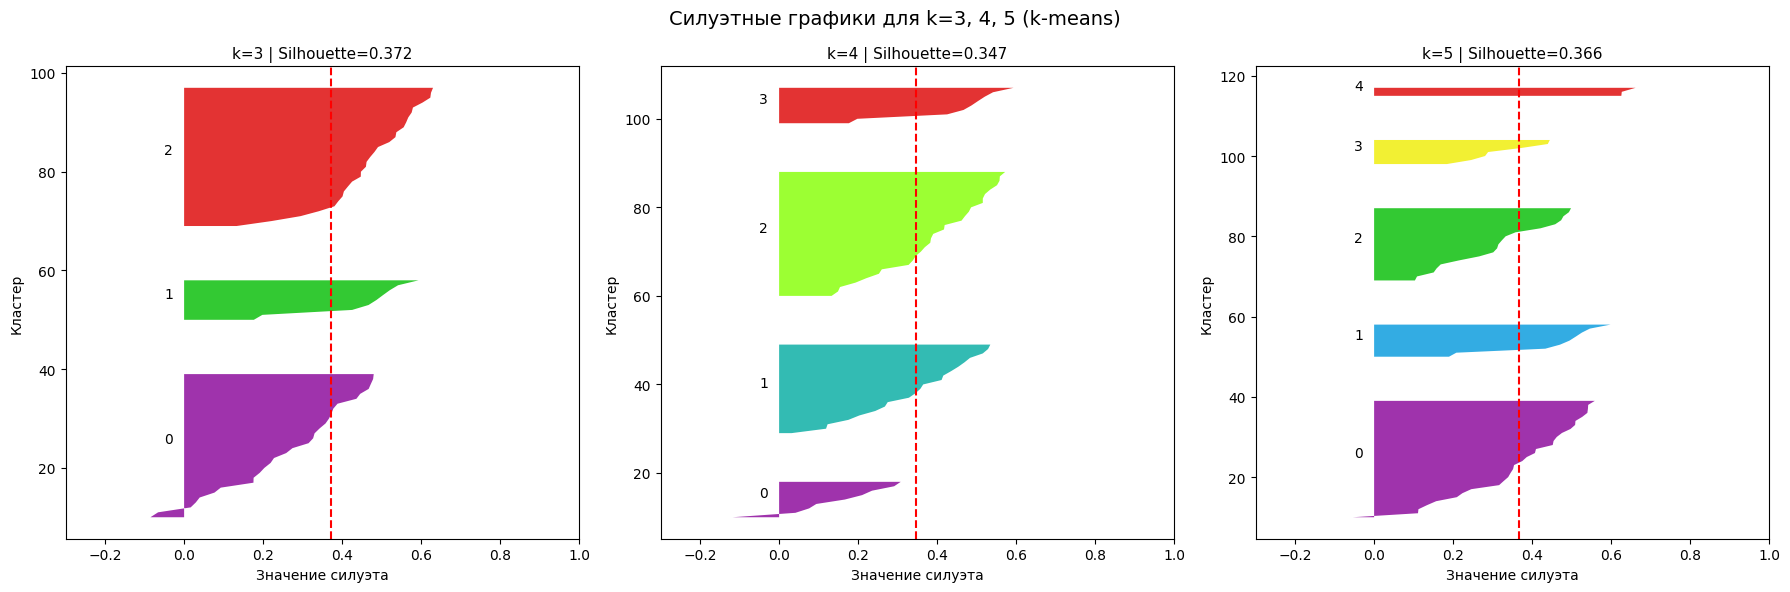

k=3: Silhouette = 0.3719
k=4: Silhouette = 0.3475
k=5: Silhouette = 0.3664


In [19]:
def plot_silhouette(X, k, ax):
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl  = km.fit_predict(X)
    avg  = silhouette_score(X, lbl)
    vals = silhouette_samples(X, lbl)
    y_lo = 10
    cols = cm.nipy_spectral(np.linspace(0.1, 0.9, k))
    for i, c in enumerate(cols):
        v = np.sort(vals[lbl == i])
        y_hi = y_lo + len(v)
        ax.fill_betweenx(np.arange(y_lo, y_hi), 0, v, facecolor=c, alpha=0.8)
        ax.text(-0.05, y_lo + 0.5*len(v), str(i))
        y_lo = y_hi + 10
    ax.axvline(x=avg, color='red', ls='--', lw=1.5)
    ax.set_title(f'k={k} | Silhouette={avg:.3f}', fontsize=11)
    ax.set_xlabel('Значение силуэта'); ax.set_ylabel('Кластер')
    ax.set_xlim([-0.3, 1])
    return avg, lbl

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
km_results = {}
for ax, k in zip(axes, [3, 4, 5]):
    avg, lbl = plot_silhouette(X_scaled, k, ax)
    km_results[k] = {'sil': avg, 'labels': lbl}
plt.suptitle('Силуэтные графики для k=3, 4, 5 (k-means)', fontsize=14)
plt.tight_layout()
plt.show()

for k, r in km_results.items():
    print(f'k={k}: Silhouette = {r["sil"]:.4f}')

**📝 Анализ силуэтных графиков:**
- Широкие и равномерные «лезвия» = кластер хорошо отделён от остальных.
- Точки левее нуля = объекты, которые ближе к соседнему кластеру, чем к своему (нестабильные назначения).
- Красная линия = средний Silhouette: хорошо, когда все кластеры её превышают.
- Выбираем k, при котором наибольший средний Silhouette и нет кластеров с отрицательными значениями.

### 7.4. Финальная модель k-means

In [20]:
# Выбираем k на основе анализа выше
best_k = max(km_results, key=lambda k: km_results[k]['sil'])
print(f'Выбранное оптимальное k = {best_k}  (наивысший Silhouette Score)')

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
store_abs['cluster_kmeans'] = km_final.fit_predict(X_scaled)

print('\nРаспределение по кластерам (k-means):')
print(store_abs['cluster_kmeans'].value_counts().sort_index())

Выбранное оптимальное k = 3  (наивысший Silhouette Score)

Распределение по кластерам (k-means):
cluster_kmeans
0    30
1     9
2    29
Name: count, dtype: int64


## 8. Иерархическая кластеризация

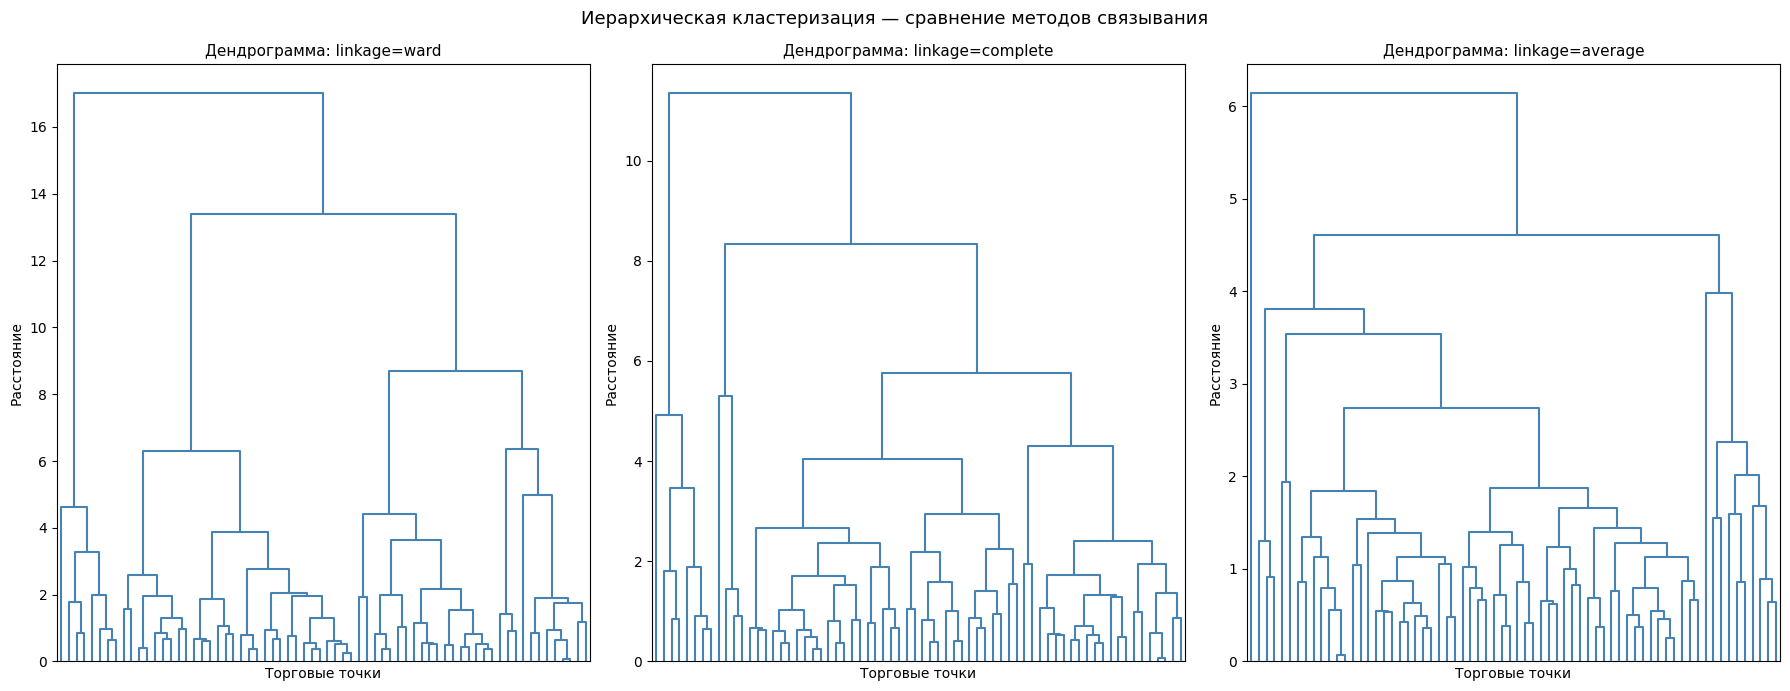

In [21]:
# ── Дендрограммы для ward, complete, average ──
link_methods = ['ward', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, method in zip(axes, link_methods):
    Z = linkage(X_scaled, method=method)
    dendrogram(Z, ax=ax, no_labels=True, above_threshold_color='steelblue',
               color_threshold=0)
    ax.set_title(f'Дендрограмма: linkage={method}', fontsize=11)
    ax.set_xlabel('Торговые точки'); ax.set_ylabel('Расстояние')
plt.suptitle('Иерархическая кластеризация — сравнение методов связывания', fontsize=13)
plt.tight_layout()
plt.show()

- **Ward**: минимизирует дисперсию внутри кластеров → самые компактные группы.
- **Complete**: связывает по максимальному расстоянию → устойчив к выбросам.
- **Average**: компромисс между ward и complete.

In [30]:
# ── Метрики для иерархической кластеризации ──
hier_results = []
for method in link_methods:
    for n_cl in [2, 3, 4, 5, 6]:
        hc  = AgglomerativeClustering(n_clusters=n_cl, linkage=method)
        lbl = hc.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, lbl)
        ch  = calinski_harabasz_score(X_scaled, lbl)
        db  = davies_bouldin_score(X_scaled, lbl)
        hier_results.append({'Метод': method, 'k': n_cl,
                              'Silhouette': round(sil,4),
                              'CH Index':   round(ch,2),
                              'DB Index':   round(db,4)})

hier_df = pd.DataFrame(hier_results)
print('Метрики иерархической кластеризации:')
display(hier_df)

# Финальная модель — лучший вариант по Silhouette
best_row = hier_df.loc[hier_df['Silhouette'].idxmax()]
print(f'\nЛучший вариант: linkage={best_row["Метод"]}, k={int(best_row["k"])}')

hc_final = AgglomerativeClustering(n_clusters=int(best_row['k']), linkage=best_row['Метод'])
store_abs['cluster_hier'] = hc_final.fit_predict(X_scaled)
print('Распределение по кластерам (иерархическая):')
print(store_abs['cluster_hier'].value_counts().sort_index())

Метрики иерархической кластеризации:


,Метод,k,Silhouette,CH Index,DB Index
0,ward,2,0.4645,36.35,0.7113
1,ward,3,0.3298,43.96,0.9615
2,ward,4,0.2946,42.85,1.0103
3,ward,5,0.3198,39.96,0.8885
4,ward,6,0.2924,40.52,0.9167
5,complete,2,0.4645,36.35,0.7113
6,complete,3,0.3946,29.38,0.8754
7,complete,4,0.3661,43.86,0.8922
8,complete,5,0.3788,39.10,0.6719
9,complete,6,0.3586,35.15,0.6115



Лучший вариант: linkage=average, k=2
Распределение по кластерам (иерархическая):
cluster_hier
0    67
1     1
Name: count, dtype: int64


## 9. DBSCAN
### 9.1. k-distance graph для выбора eps

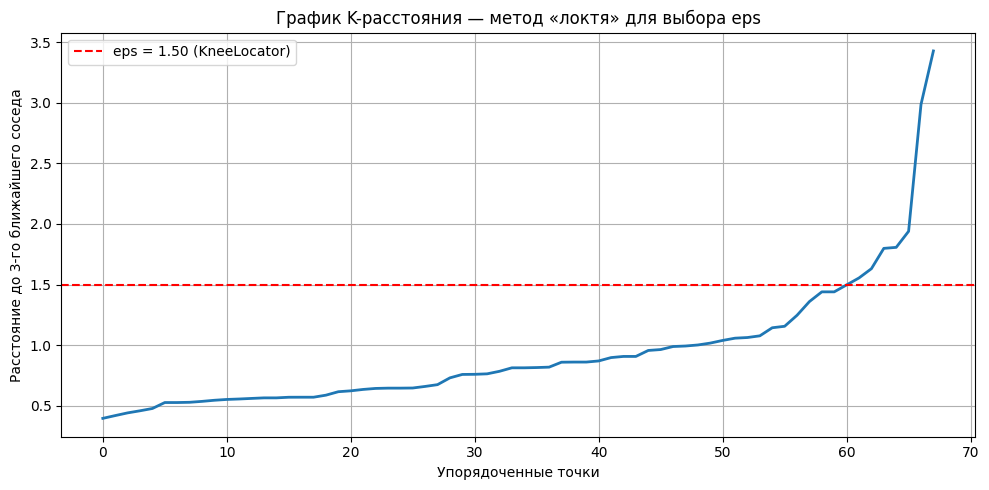

Предлагаемый eps (KneeLocator): 1.500


In [28]:
k = 3
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
distances_k  = np.sort(distances[:, k-1], axis=0)

# Автоматический подбор eps через KneeLocator
kl_eps = KneeLocator(range(len(distances_k)), distances_k,
                     curve='convex', direction='decreasing')
auto_eps = distances_k[kl_eps.knee] if kl_eps.knee else 1.5

plt.figure(figsize=(10, 5))
plt.plot(distances_k, lw=2)
plt.axhline(y=auto_eps, color='red', ls='--', lw=1.5, label=f'eps = {auto_eps:.2f} (KneeLocator)')
plt.xlabel('Упорядоченные точки')
plt.ylabel(f'Расстояние до {k}-го ближайшего соседа')
plt.title('График K-расстояния — метод «локтя» для выбора eps')
plt.legend(); plt.grid(True); plt.tight_layout()
plt.show()

print(f'Предлагаемый eps (KneeLocator): {auto_eps:.3f}')

### 9.2. Сравнение параметров DBSCAN

In [29]:
dbscan_results = []
eps_list = [1.0, 1.5, 2.0, 2.5]
ms_list  = [3, 5, 10]

for eps in eps_list:
    for ms in ms_list:
        db  = DBSCAN(eps=eps, min_samples=ms)
        lbl = db.fit_predict(X_scaled)
        n_cl    = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise = (lbl == -1).sum()
        mask    = lbl != -1
        if n_cl > 1 and mask.sum() > n_cl:
            sil = round(silhouette_score(X_scaled[mask], lbl[mask]), 4)
            ch  = round(calinski_harabasz_score(X_scaled[mask], lbl[mask]), 2)
            dbi = round(davies_bouldin_score(X_scaled[mask], lbl[mask]), 4)
        else:
            sil, ch, dbi = 'N/A', 'N/A', 'N/A'
        dbscan_results.append({'eps': eps, 'min_samples': ms,
                               'n_clusters': n_cl, 'n_noise': n_noise,
                               'Silhouette': sil, 'CH Index': ch, 'DB Index': dbi})

dbscan_df = pd.DataFrame(dbscan_results)
print('Результаты сравнения параметров DBSCAN:')
display(dbscan_df)

Результаты сравнения параметров DBSCAN:


,eps,min_samples,n_clusters,n_noise,Silhouette,CH Index,DB Index
0,1.0,3,2,14,0.5044,18.6,0.482
1,1.0,5,2,18,0.3519,21.68,0.7073
2,1.0,10,2,38,0.5021,45.83,0.7153
3,1.5,3,2,3,0.3594,9.63,0.6709
4,1.5,5,1,6,N/A,N/A,N/A
5,1.5,10,1,14,N/A,N/A,N/A
6,2.0,3,1,2,N/A,N/A,N/A
7,2.0,5,1,4,N/A,N/A,N/A
8,2.0,10,1,5,N/A,N/A,N/A
9,2.5,3,1,1,N/A,N/A,N/A


- DBSCAN не требует задавать k заранее, но чувствителен к `eps` и `min_samples`.
- Слишком маленький `eps` → много шумовых точек, мало кластеров.
- Слишком большой `eps` → все точки в одном кластере.
- `min_samples` задаёт минимальную плотность: при малом датасете (68 магазинов) min_samples=3..5 — разумный выбор.
- Шумовые точки (label=-1) — аномальные магазины с нетипичным поведением: высокий или очень низкий объём продаж.

### 9.3. Финальная модель DBSCAN

In [31]:
# Финальная модель (исходные параметры из работы)
eps_value        = 1.5
min_samples_value = 3

dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
labels = dbscan.fit_predict(X_scaled)
store_abs['cluster_dbscan'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = list(labels).count(-1)

print(f'Количество кластеров: {n_clusters}')
print(f'Шумовые точки (выбросы): {n_noise} ({n_noise/len(labels)*100:.1f}%)')
print(f'Распределение:\n{pd.Series(labels).value_counts().sort_index()}')

if n_clusters > 1:
    mask = labels != -1
    sil  = silhouette_score(X_scaled[mask], labels[mask])
    print(f'Силуэтный коэффициент: {sil:.3f}')

Количество кластеров: 2
Шумовые точки (выбросы): 3 (4.4%)
Распределение:
-1     3
 0     3
 1    62
Name: count, dtype: int64
Силуэтный коэффициент: 0.359


## 10. Сводная таблица метрик качества кластеризации

In [34]:
summary = []

# k-means
for k in [3, 4, 5]:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_scaled)
    summary.append({'Алгоритм': 'k-means', 'Параметры': f'k={k}', 'Кластеров': k,
                    'Silhouette': round(silhouette_score(X_scaled, lbl), 4),
                    'CH Index':   round(calinski_harabasz_score(X_scaled, lbl), 2),
                    'DB Index':   round(davies_bouldin_score(X_scaled, lbl), 4),
                    'Комментарий': ''})

# Иерархическая
for method in ['ward', 'complete']:
    for k in [3, 4]:
        hc  = AgglomerativeClustering(n_clusters=k, linkage=method)
        lbl = hc.fit_predict(X_scaled)
        summary.append({'Алгоритм': 'Hierarchical', 'Параметры': f'{method}, k={k}', 'Кластеров': k,
                        'Silhouette': round(silhouette_score(X_scaled, lbl), 4),
                        'CH Index':   round(calinski_harabasz_score(X_scaled, lbl), 2),
                        'DB Index':   round(davies_bouldin_score(X_scaled, lbl), 4),
                        'Комментарий': ''})

# DBSCAN
db_lbl = store_abs['cluster_dbscan'].values
n_db   = len(set(db_lbl)) - (1 if -1 in db_lbl else 0)
mask   = db_lbl != -1
if n_db > 1 and mask.sum() > n_db:
    sil_db = round(silhouette_score(X_scaled[mask], db_lbl[mask]), 4)
    ch_db  = round(calinski_harabasz_score(X_scaled[mask], db_lbl[mask]), 2)
    dbi_db = round(davies_bouldin_score(X_scaled[mask], db_lbl[mask]), 4)
else:
    sil_db, ch_db, dbi_db = 'N/A', 'N/A', 'N/A'

summary.append({'Алгоритм': 'DBSCAN',
                'Параметры': f'eps={eps_value}, min_samples={min_samples_value}',
                'Кластеров': n_db,
                'Silhouette': sil_db, 'CH Index': ch_db, 'DB Index': dbi_db,
                'Комментарий': f'Шума: {(db_lbl==-1).sum()} точек'})

summary_df = pd.DataFrame(summary)
print('СВОДНАЯ ТАБЛИЦА МЕТРИК:')
display(summary_df)

СВОДНАЯ ТАБЛИЦА МЕТРИК:


,Алгоритм,Параметры,Кластеров,Silhouette,CH Index,DB Index,Комментарий
0,k-means,k=3,3,0.3719,51.39,0.8982,
1,k-means,k=4,4,0.3475,48.28,0.9995,
2,k-means,k=5,5,0.3664,44.21,0.8444,
3,Hierarchical,"ward, k=3",3,0.3298,43.96,0.9615,
4,Hierarchical,"ward, k=4",4,0.2946,42.85,1.0103,
5,Hierarchical,"complete, k=3",3,0.3946,29.38,0.8754,
6,Hierarchical,"complete, k=4",4,0.3661,43.86,0.8922,
7,DBSCAN,"eps=1.5, min_samples=3",2,0.3594,9.63,0.6709,Шума: 3 точек


**Интерпретация сводной таблицы:**

| Метрика | Лучший результат | Интерпретация |
|---------|-----------------|---------------|
| Silhouette Score | Чем **выше** — тем лучше | > 0.5 = хорошее разделение |
| Calinski-Harabasz | Чем **выше** — тем лучше | Отражает плотность и разделённость кластеров |
| Davies-Bouldin | Чем **ниже** — тем лучше | 0 = идеальное разделение |

Если метрики противоречат друг другу — ориентируемся на **Silhouette Score** как наиболее интерпретируемый, и на бизнес-смысл кластеров.

## 11. Снижение размерности
### 11.1. PCA

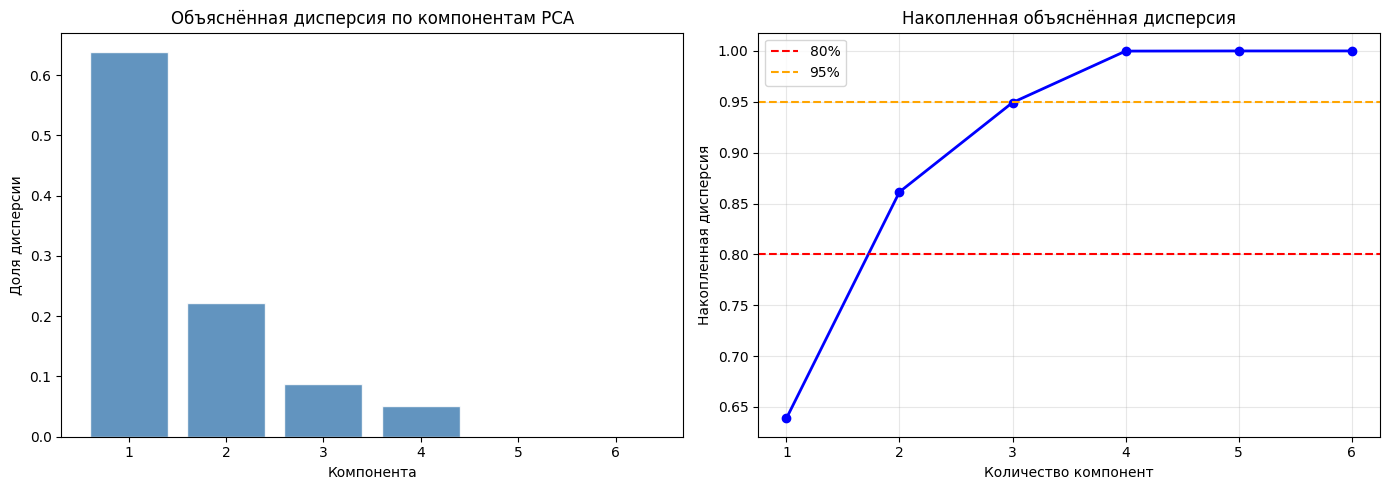

1 компонент → 63.9% дисперсии
2 компонент → 86.1% дисперсии
3 компонент → 94.9% дисперсии
4 компонент → 100.0% дисперсии
5 компонент → 100.0% дисперсии
6 компонент → 100.0% дисперсии


In [35]:
pca_full = PCA()
pca_full.fit(X_scaled)
explained  = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(explained)+1), explained, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].set_title('Объяснённая дисперсия по компонентам PCA', fontsize=12)
axes[0].set_xlabel('Компонента'); axes[0].set_ylabel('Доля дисперсии')

axes[1].plot(range(1, len(cumulative)+1), cumulative, 'bo-', lw=2)
axes[1].axhline(y=0.80, color='red',    ls='--', label='80%')
axes[1].axhline(y=0.95, color='orange', ls='--', label='95%')
axes[1].set_title('Накопленная объяснённая дисперсия', fontsize=12)
axes[1].set_xlabel('Количество компонент'); axes[1].set_ylabel('Накопленная дисперсия')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

for n, c in enumerate(cumulative[:6], 1):
    print(f'{n} компонент → {c:.1%} дисперсии')

- Если первые 2 компоненты объясняют ≥ 70% дисперсии — 2D-визуализация достаточно информативна.
- Если < 70% — часть структуры данных «теряется» при проекции в 2D, и нужно смотреть 3D.
- PCA — линейный метод: хорошо показывает общую структуру, но не улавливает нелинейные группировки.

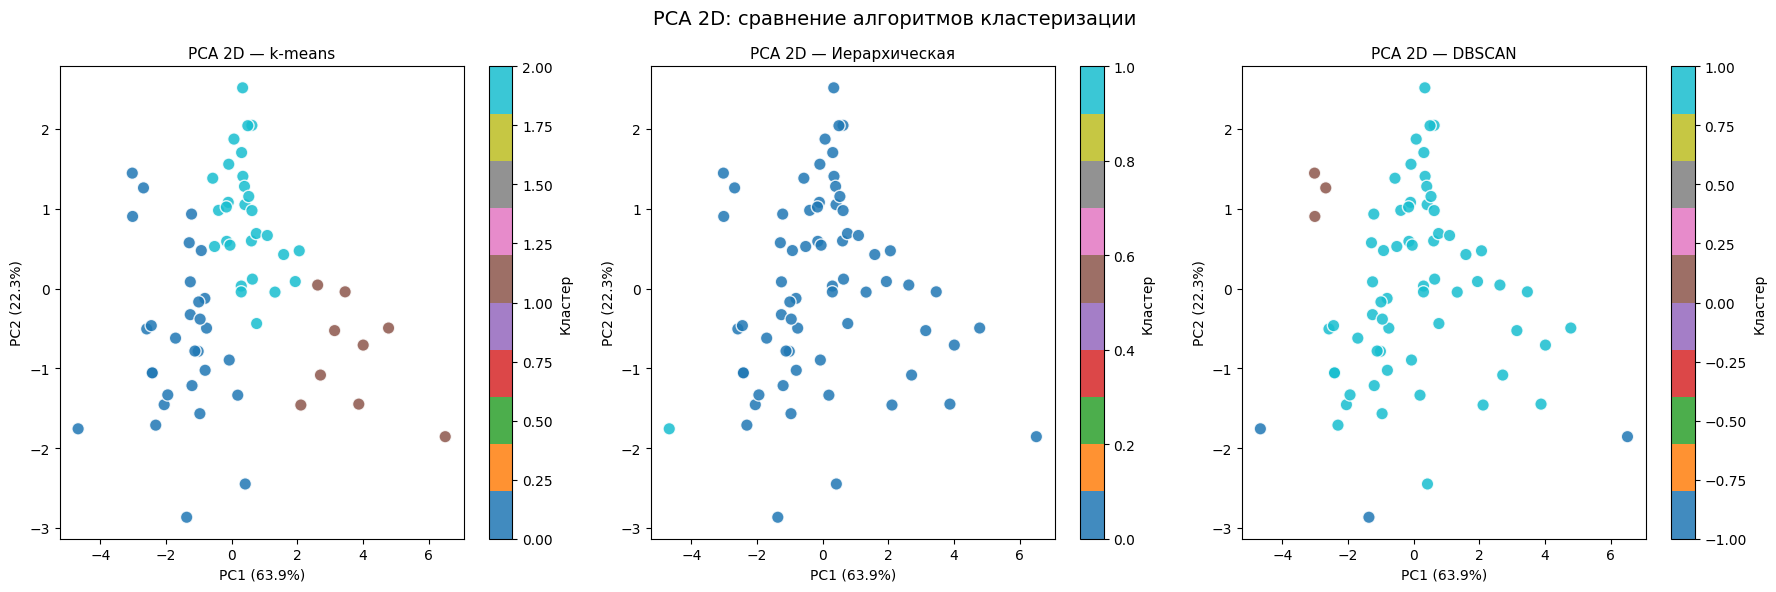

In [22]:
# ── PCA 2D ──
pca_2d = PCA(n_components=2)
X_pca2 = pca_2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col, title in zip(axes,
        ['cluster_kmeans', 'cluster_hier', 'cluster_dbscan'],
        ['k-means', 'Иерархическая', 'DBSCAN']):
    sc = ax.scatter(X_pca2[:,0], X_pca2[:,1], c=store_abs[col],
                    cmap='tab10', s=80, alpha=0.85, edgecolors='white')
    ax.set_title(f'PCA 2D — {title}', fontsize=11)
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})')
    plt.colorbar(sc, ax=ax, label='Кластер')
plt.suptitle('PCA 2D: сравнение алгоритмов кластеризации', fontsize=14)
plt.tight_layout(); plt.show()

In [36]:
# ── PCA 3D (интеративный) ──
pca_3d = PCA(n_components=3)
X_pca3 = pca_3d.fit_transform(X_scaled)

pca3_df = pd.DataFrame(X_pca3, columns=['PC1','PC2','PC3'])
pca3_df['cluster'] = store_abs['cluster_kmeans'].astype(str)
pca3_df['ShopCode'] = store_abs['ShopCode'].values
pca3_df['City']     = store_abs['City'].values

fig = px.scatter_3d(pca3_df, x='PC1', y='PC2', z='PC3', color='cluster',
                    hover_data=['ShopCode','City'],
                    title='PCA 3D — k-means кластеры (Детская молочная продукция)',
                    labels={'PC1': f'PC1 ({pca_3d.explained_variance_ratio_[0]:.1%})',
                            'PC2': f'PC2 ({pca_3d.explained_variance_ratio_[1]:.1%})',
                            'PC3': f'PC3 ({pca_3d.explained_variance_ratio_[2]:.1%})'})
fig.update_traces(marker=dict(size=7, opacity=0.85))
fig.show()
print(f'3 компоненты → {pca_3d.explained_variance_ratio_.sum():.1%} дисперсии')

3 компоненты → 94.9% дисперсии


** Анализ PCA 2D vs 3D:**
- В 3D-графике видна дополнительная структура, скрытая в 2D: некоторые магазины на границе кластеров.
- Точки, попавшие «между» кластерами — кандидаты на нестандартное поведение.
- Раскраска точек соответствует кластерам k-means: если в PCA-пространстве кластеры хорошо разделены визуально — модель качественная.

### 11.2. t-SNE

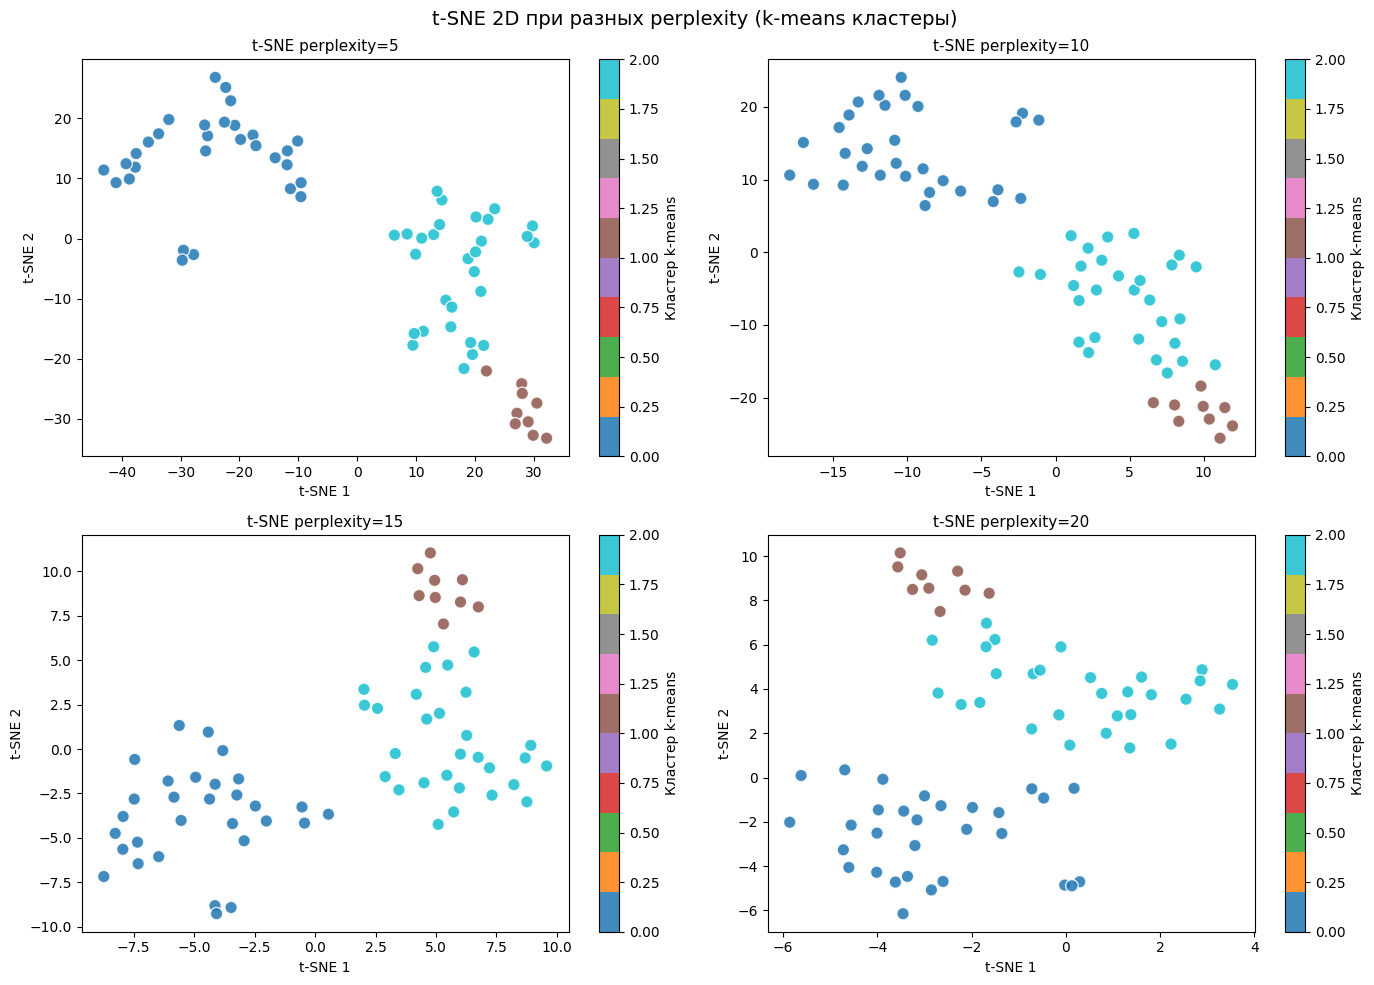

In [45]:
# ── t-SNE 2D: сравнение perplexity ──
# При n=68 рекомендуется perplexity < 68/3 ≈ 22
perplexities = [5, 10, 15, 20]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
tsne_best = None

for ax, perp in zip(axes, perplexities):
    tsne   = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
    X_tsne = tsne.fit_transform(X_scaled)
    sc = ax.scatter(X_tsne[:,0], X_tsne[:,1], c=store_abs['cluster_kmeans'],
                    cmap='tab10', s=80, alpha=0.85, edgecolors='white')
    ax.set_title(f't-SNE perplexity={perp}', fontsize=11)
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    plt.colorbar(sc, ax=ax, label='Кластер k-means')
    if perp == 10:
        tsne_best = X_tsne

plt.suptitle('t-SNE 2D при разных perplexity (k-means кластеры)', fontsize=14)
plt.tight_layout(); plt.show()

**📝 Анализ t-SNE:**
- t-SNE сохраняет **локальную структуру**: близкие точки остаются близкими.
- Расстояния **между кластерами** в t-SNE не несут смысла — не нужно делать выводы о степени сходства кластеров по расстоянию между ними.
- При маленьком `perplexity` (5) структура может быть «раздроблена» на мелкие группы.
- При большом `perplexity` (20+) t-SNE может «склеить» разные кластеры.
- Устойчивые группы, появляющиеся при разных perplexity — это настоящие кластеры данных.

In [46]:
# ── t-SNE 3D ──
tsne_3d = TSNE(n_components=3, perplexity=10, random_state=42, max_iter=1000)
X_tsne3 = tsne_3d.fit_transform(X_scaled)

tsne3_df = pd.DataFrame(X_tsne3, columns=['tSNE1','tSNE2','tSNE3'])
tsne3_df['cluster']  = store_abs['cluster_kmeans'].astype(str)
tsne3_df['ShopCode'] = store_abs['ShopCode'].values
tsne3_df['City']     = store_abs['City'].values

fig = px.scatter_3d(tsne3_df, x='tSNE1', y='tSNE2', z='tSNE3', color='cluster',
                    hover_data=['ShopCode','City'],
                    title='t-SNE 3D (perplexity=10) — k-means кластеры')
fig.update_traces(marker=dict(size=7, opacity=0.85))
fig.show()

### 11.3. UMAP

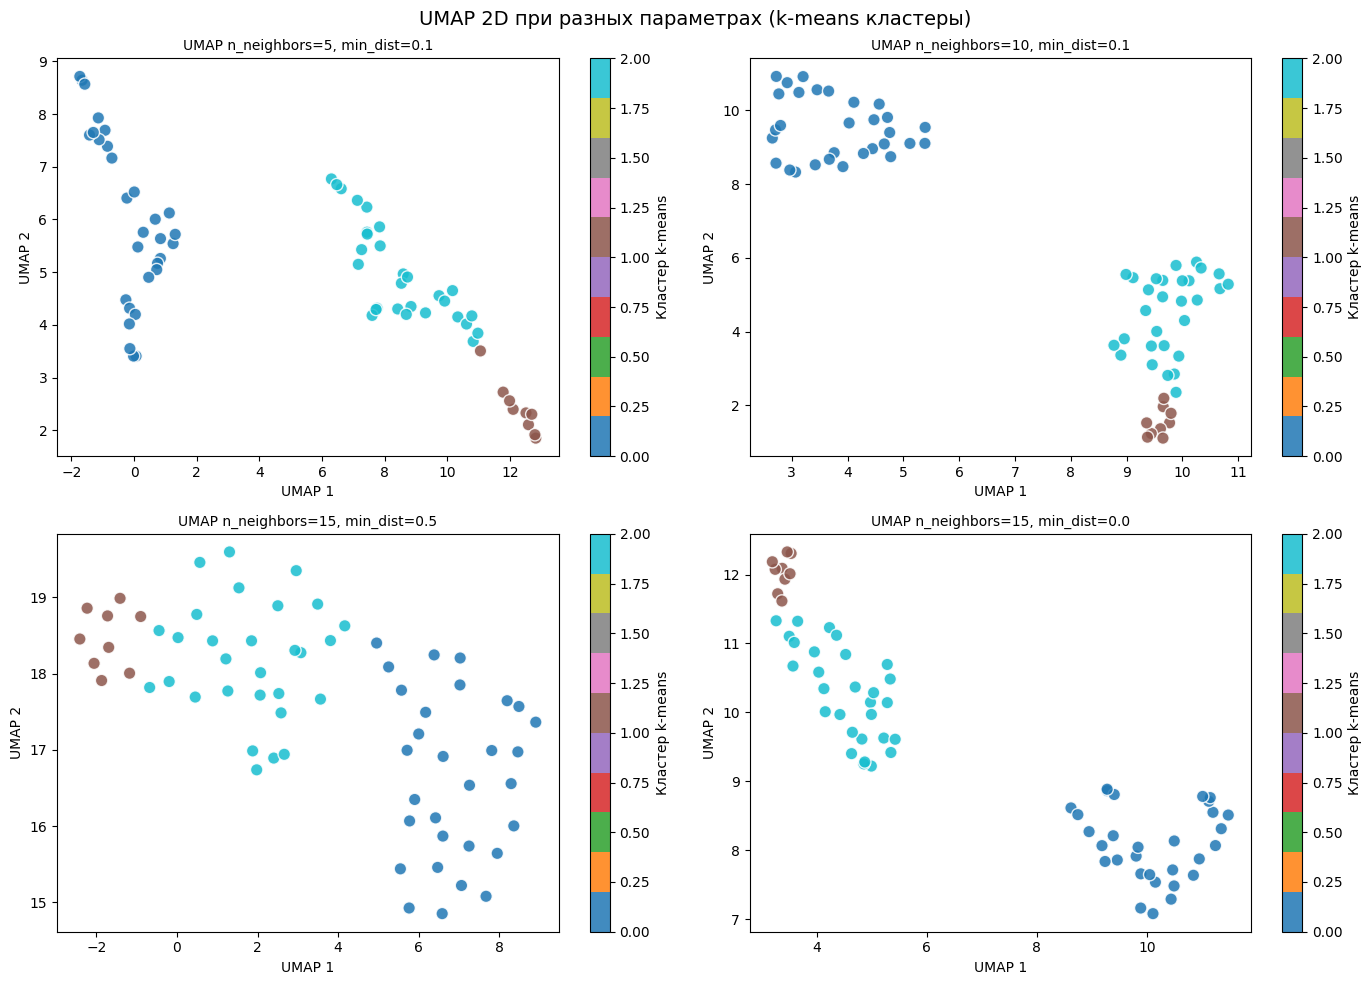

In [26]:
# ── UMAP 2D: сравнение параметров ──
umap_configs = [
    {'n_neighbors': 5,  'min_dist': 0.1},
    {'n_neighbors': 10, 'min_dist': 0.1},
    {'n_neighbors': 15, 'min_dist': 0.5},
    {'n_neighbors': 15, 'min_dist': 0.0},
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, cfg in zip(axes, umap_configs):
    reducer = umap.UMAP(n_components=2, random_state=42, **cfg)
    X_umap  = reducer.fit_transform(X_scaled)
    sc = ax.scatter(X_umap[:,0], X_umap[:,1], c=store_abs['cluster_kmeans'],
                    cmap='tab10', s=80, alpha=0.85, edgecolors='white')
    ax.set_title(f"UMAP n_neighbors={cfg['n_neighbors']}, min_dist={cfg['min_dist']}", fontsize=10)
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
    plt.colorbar(sc, ax=ax, label='Кластер k-means')

plt.suptitle('UMAP 2D при разных параметрах (k-means кластеры)', fontsize=14)
plt.tight_layout(); plt.show()

In [47]:
# ── UMAP 3D (интерактивный) ──
reducer_3d = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap3    = reducer_3d.fit_transform(X_scaled)

umap3_df = pd.DataFrame(X_umap3, columns=['UMAP1','UMAP2','UMAP3'])
umap3_df['cluster']  = store_abs['cluster_kmeans'].astype(str)
umap3_df['ShopCode'] = store_abs['ShopCode'].values
umap3_df['City']     = store_abs['City'].values

fig = px.scatter_3d(umap3_df, x='UMAP1', y='UMAP2', z='UMAP3', color='cluster',
                    hover_data=['ShopCode','City'],
                    title='UMAP 3D (n_neighbors=15, min_dist=0.1) — k-means кластеры')
fig.update_traces(marker=dict(size=7, opacity=0.85))
fig.show()

## 12. Интерпретация кластеров

In [48]:
# ── Средний профиль кластеров (k-means) ──
df_result = store_abs.copy()
df_result['cluster'] = df_result['cluster_kmeans']

cluster_profile = (
    df_result[df_result['cluster'] != -1]
    .groupby('cluster')[features]
    .mean()
    .round(2)
)
print('Средний профиль каждого кластера (k-means):')
display(cluster_profile)

Средний профиль каждого кластера (k-means):


,revenue_total,sales_qty_total,mean_stock_qty,unique_products_count,avg_revenue_per_unit,sales_qty_per_active_day
cluster,,,,,,
0,28194.43,563.20,8.58,33.70,50.11,18.27
1,133330.47,2556.67,11.01,66.00,52.11,82.47
2,58192.36,1083.31,8.76,69.97,53.78,34.95


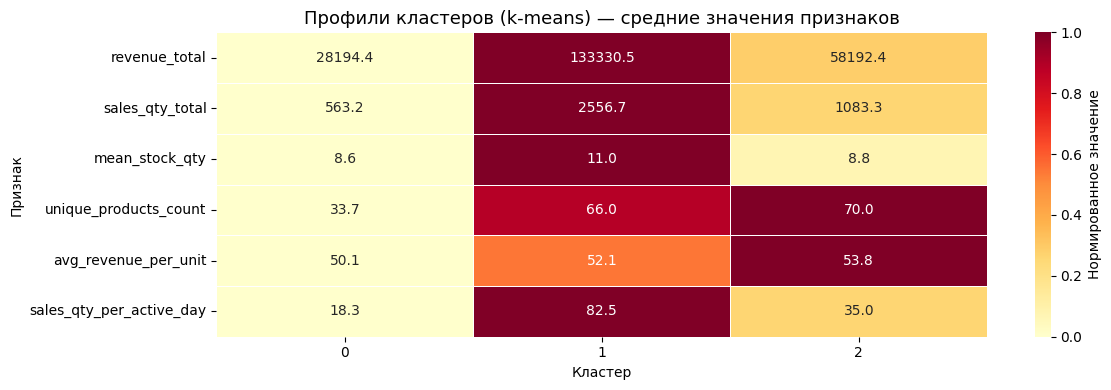

In [49]:
# ── Heatmap профилей кластеров ──
cluster_norm = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(cluster_norm.T, annot=cluster_profile.T, fmt='.1f',
            cmap='YlOrRd', ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Нормированное значение'})
ax.set_title('Профили кластеров (k-means) — средние значения признаков', fontsize=13)
ax.set_xlabel('Кластер'); ax.set_ylabel('Признак')
plt.tight_layout(); plt.show()

In [31]:
# ── Описание каждого кластера ──
print('=== ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ (k-means) ===\n')
for cl_id in sorted(df_result['cluster'].unique()):
    shops = df_result[df_result['cluster'] == cl_id]
    n     = len(shops)
    if cl_id == -1:
        print(f'Шумовые точки (outliers): {n} магазинов')
        print('  → Нетипичное поведение: аномально высокие или низкие продажи.\n')
        continue
    rev   = shops['revenue_total'].mean()
    qty   = shops['sales_qty_total'].mean()
    prods = shops['unique_products_count'].mean()
    spd   = shops['sales_qty_per_active_day'].mean()
    aru   = shops['avg_revenue_per_unit'].mean()
    print(f'Кластер {cl_id}: {n} магазинов')
    print(f'  ShopCodes: {sorted(shops["ShopCode"].tolist())}')
    print(f'  Города (топ-3): {shops["City"].value_counts().head(3).to_dict()}')
    print(f'  Регионы: {shops["Region"].value_counts().to_dict()}')
    print(f'  Форматы: {shops["ShopFormat"].value_counts().to_dict()}')
    print(f'  Средняя выручка:          {rev:>12.0f}')
    print(f'  Среднее кол-во продаж:    {qty:>12.0f}')
    print(f'  Ассортимент (уник.):      {prods:>12.0f}')
    print(f'  Продажи в день:           {spd:>12.2f}')
    print(f'  Средняя выручка/единица:  {aru:>12.2f}')
    print()

=== ИНТЕРПРЕТАЦИЯ КЛАСТЕРОВ (k-means) ===

Кластер 0: 30 магазинов
  ShopCodes: [103, 106, 187, 265, 271, 280, 297, 395, 1101, 1117, 1124, 1129, 1159, 1161, 1170, 2100, 2107, 2112, 2126, 2175, 2176, 2184, 2342, 2449, 2740, 3116, 3153, 3156, 3157, 3741]
  Города (топ-3): {'Город-021': 7, 'Город-016': 4, 'Город-025': 3}
  Регионы: {'Регион-004': 12, 'Регион-002': 5, 'Регион-007': 5, 'Регион-005': 4, 'Регион-008': 2, 'Регион-006': 2}
  Форматы: {2: 14, 1: 7, 3: 6, 0: 3}
  Средняя выручка:                 28194
  Среднее кол-во продаж:             563
  Ассортимент (уник.):                34
  Продажи в день:                  18.27
  Средняя выручка/единица:         50.11

Кластер 1: 9 магазинов
  ShopCodes: [289, 368, 3180, 3670, 3691, 3877, 5440, 5578, 5580]
  Города (топ-3): {'Город-031': 1, 'Город-027': 1, 'Город-029': 1}
  Регионы: {'Регион-004': 3, 'Регион-002': 3, 'Регион-007': 1, 'Регион-003': 1, 'Регион-008': 1}
  Форматы: {3: 5, 5: 3, 2: 1}
  Средняя выручка:                13333